In [ ]:
from google.colab import files
uploaded=files.upload()

Saving data (1).csv to data (1).csv


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)


In [ ]:
# STEP 1: LOAD DATA
# -------------------------
df = pd.read_csv("data.csv")
df.columns = df.columns.str.strip()
print("\nFirst 5 rows")
print(df.head())

# Accept either target or condition column
if "target" in df.columns:
    target_col = "target"
elif "condition" in df.columns:
    target_col = "condition"
elif "num" in df.columns:
    target_col = "num"
else:
    raise ValueError("Dataset must contain 'target', 'condition' or 'num' column.")

print("\nDataset Shape:", df.shape)
print(df.info())
print(df.describe())


First 5 rows
   age  sex  cp trestbps chol fbs restecg thalach exang  oldpeak slope ca  \
0   28    1   2      130  132   0       2     185     0      0.0     ?  ?   
1   29    1   2      120  243   0       0     160     0      0.0     ?  ?   
2   29    1   2      140    ?   0       0     170     0      0.0     ?  ?   
3   30    0   1      170  237   0       1     170     0      0.0     ?  ?   
4   31    0   2      100  219   0       1     150     0      0.0     ?  ?   

  thal  num  
0    ?    0  
1    ?    0  
2    ?    0  
3    6    0  
4    ?    0  

Dataset Shape: (294, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  294 non-null    object 
 4   chol      294 non-null    object 
 5   fbs       294 non-null    obje


MODEL EVALUATION

Logistic Regression
Accuracy : 0.8305
Precision: 0.7895
Recall   : 0.7143
F1 Score : 0.75
ROC AUC  : 0.8847
CV Mean  : 0.8402

Confusion Matrix
[[34  4]
 [ 6 15]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87        38
         1.0       0.79      0.71      0.75        21

    accuracy                           0.83        59
   macro avg       0.82      0.80      0.81        59
weighted avg       0.83      0.83      0.83        59



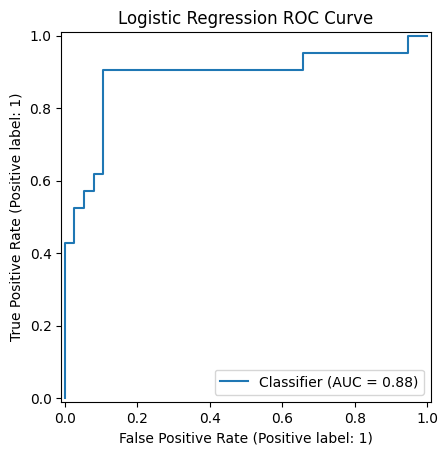


Decision Tree
Accuracy : 0.7458
Precision: 0.625
Recall   : 0.7143
F1 Score : 0.6667
ROC AUC  : 0.7387
CV Mean  : 0.6589

Confusion Matrix
[[29  9]
 [ 6 15]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.83      0.76      0.79        38
         1.0       0.62      0.71      0.67        21

    accuracy                           0.75        59
   macro avg       0.73      0.74      0.73        59
weighted avg       0.76      0.75      0.75        59



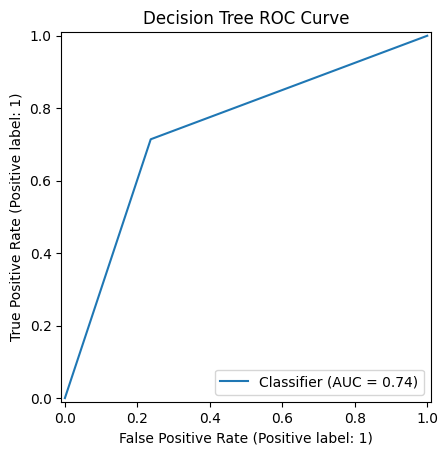


Random Forest
Accuracy : 0.8644
Precision: 0.8095
Recall   : 0.8095
F1 Score : 0.8095
ROC AUC  : 0.9073
CV Mean  : 0.7439

Confusion Matrix
[[34  4]
 [ 4 17]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89        38
         1.0       0.81      0.81      0.81        21

    accuracy                           0.86        59
   macro avg       0.85      0.85      0.85        59
weighted avg       0.86      0.86      0.86        59



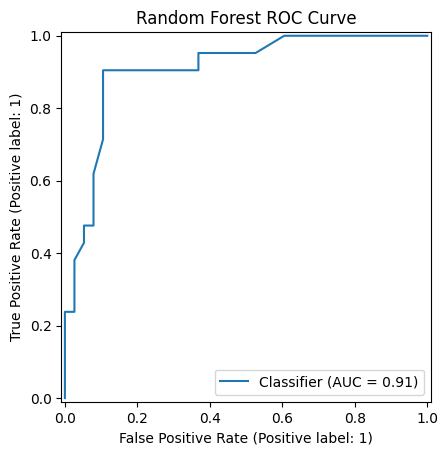


KNN
Accuracy : 0.8475
Precision: 0.8
Recall   : 0.7619
F1 Score : 0.7805
ROC AUC  : 0.8872
CV Mean  : 0.8231

Confusion Matrix
[[34  4]
 [ 5 16]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88        38
         1.0       0.80      0.76      0.78        21

    accuracy                           0.85        59
   macro avg       0.84      0.83      0.83        59
weighted avg       0.85      0.85      0.85        59



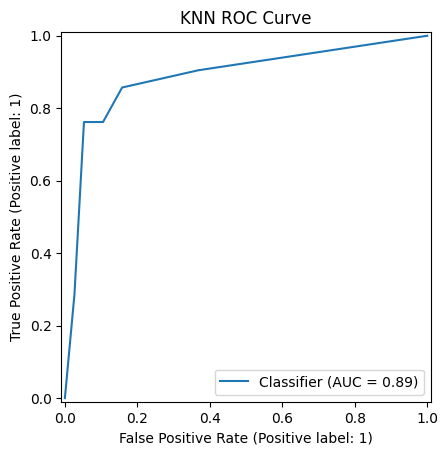


SVM
Accuracy : 0.8814
Precision: 0.85
Recall   : 0.8095
F1 Score : 0.8293
ROC AUC  : 0.9198
CV Mean  : 0.8334

Confusion Matrix
[[35  3]
 [ 4 17]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.90      0.92      0.91        38
         1.0       0.85      0.81      0.83        21

    accuracy                           0.88        59
   macro avg       0.87      0.87      0.87        59
weighted avg       0.88      0.88      0.88        59



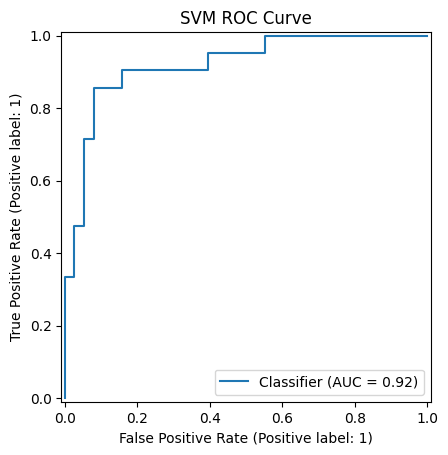


Naive Bayes
Accuracy : 0.8305
Precision: 0.7037
Recall   : 0.9048
F1 Score : 0.7917
ROC AUC  : 0.8747
CV Mean  : 0.7858

Confusion Matrix
[[30  8]
 [ 2 19]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.94      0.79      0.86        38
         1.0       0.70      0.90      0.79        21

    accuracy                           0.83        59
   macro avg       0.82      0.85      0.82        59
weighted avg       0.85      0.83      0.83        59



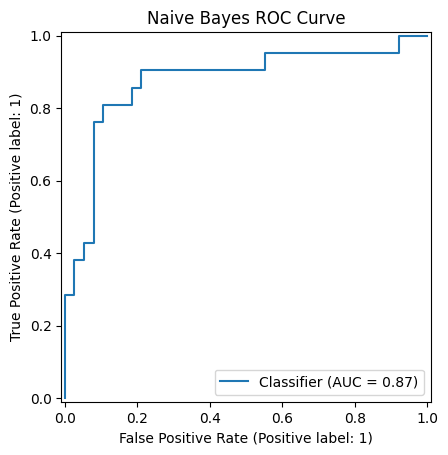


MODEL COMPARISON
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC  \
4                  SVM  0.881356   0.850000  0.809524  0.829268  0.919799   
2        Random Forest  0.864407   0.809524  0.809524  0.809524  0.907268   
3                  KNN  0.847458   0.800000  0.761905  0.780488  0.887218   
0  Logistic Regression  0.830508   0.789474  0.714286  0.750000  0.884712   
5          Naive Bayes  0.830508   0.703704  0.904762  0.791667  0.874687   
1        Decision Tree  0.745763   0.625000  0.714286  0.666667  0.738722   

   CV Accuracy  
4     0.833372  
2     0.743892  
3     0.823144  
0     0.840152  
5     0.785798  
1     0.658913  

Best Model: SVM

Running GridSearchCV...

Best Parameters
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Optimized Random Forest Results
Accuracy : 0.864406779661017
Precision: 0.8421052631578947
Recall   : 0.7619047619047619
F1 Score : 0.8
ROC AUC  : 0.9072681704260651

Top 10 Important Features
     Fea

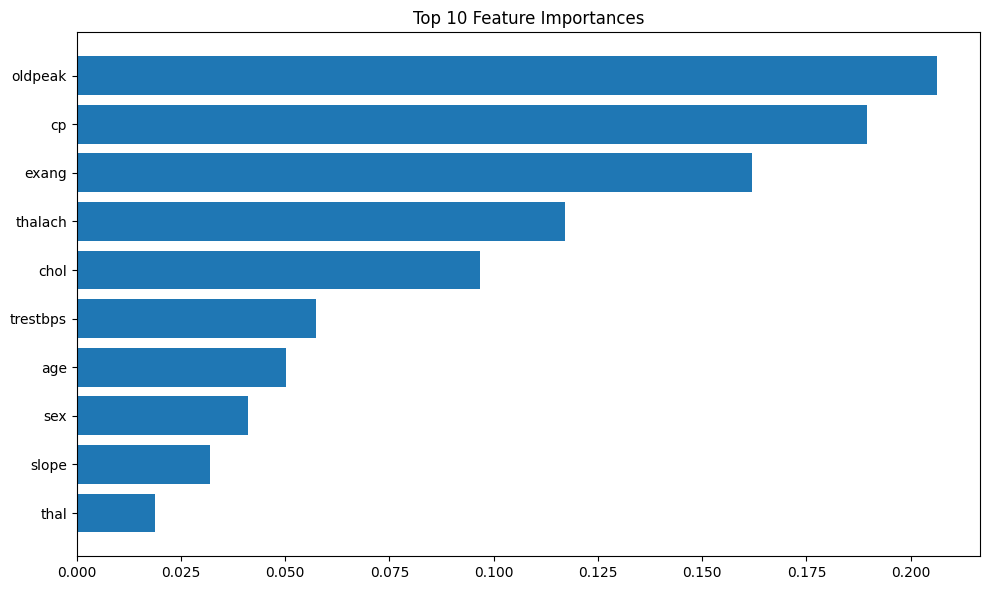


Finished.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# STEP 1: LOAD DATA (re-added for robustness)
# -------------------------
df = pd.read_csv("data (1).csv")
df.columns = df.columns.str.strip()

# Accept either target or condition column (re-added for robustness)
if "target" in df.columns:
    target_col = "target"
elif "condition" in df.columns:
    target_col = "condition"
elif "num" in df.columns:
    target_col = "num"
else:
    raise ValueError("Dataset must contain 'target', 'condition' or 'num' column.")

# STEP 2: PREPROCESSING
# -------------------------
# Replace '?' with NaN
df = df.replace('?', np.nan)

# Convert columns to numeric, coercing errors will turn non-numeric into NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute missing values with the median strategy
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df = df_imputed


# STEP 3: SPLIT
# -------------------------
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic Regression":
        Pipeline([("scaler", StandardScaler()),
                  ("model", LogisticRegression(max_iter=1000))]),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "KNN":
        Pipeline([("scaler", StandardScaler()),
                  ("model", KNeighborsClassifier())]),

    "SVM":
        Pipeline([("scaler", StandardScaler()),
                  ("model", SVC(probability=True))]),

    "Naive Bayes":
        GaussianNB()
}

results = []

print("\n==========================")
print("MODEL EVALUATION")
print("==========================")

best_model = None
best_auc = -1

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:,1]
    else:
        prob = model.decision_function(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)

    cv = cross_val_score(model, X, y, cv=5, scoring="accuracy")

    print("\n", "="*60)
    print(name)
    print("="*60)
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(auc,4))
    print("CV Mean  :", round(cv.mean(),4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test,pred))

    print("\nClassification Report")
    print(classification_report(y_test,pred))

    RocCurveDisplay.from_predictions(y_test, prob)
    plt.title(name + " ROC Curve")
    plt.show()

    results.append([name,acc,prec,rec,f1,auc,cv.mean()])

    if auc > best_auc:
        best_auc = auc
        best_model = (name, model)

summary = pd.DataFrame(
    results,
    columns=[
        "Model","Accuracy","Precision","Recall",
        "F1","ROC_AUC","CV Accuracy"
    ]
)

summary = summary.sort_values("ROC_AUC",ascending=False)

print("\nMODEL COMPARISON")
print(summary)

print("\nBest Model:", best_model[0])

# -------------------------
# GRID SEARCH (Random Forest)
# -------------------------
print("\nRunning GridSearchCV...")

params = {
    "n_estimators":[50,100,200],
    "max_depth":[None,5,10],
    "min_samples_split":[2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

print("\nBest Parameters")
print(grid.best_params_)

best_rf = grid.best_estimator_

pred = best_rf.predict(X_test)
prob = best_rf.predict_proba(X_test)[:,1]

print("\nOptimized Random Forest Results")
print("Accuracy :", accuracy_score(y_test,pred))
print("Precision:", precision_score(y_test,pred))
print("Recall   :", recall_score(y_test,pred))
print("F1 Score :", f1_score(y_test,pred))
print("ROC AUC  :", roc_auc_score(y_test,prob))

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf.feature_importances_
}).sort_values("Importance",ascending=False)

print("\nTop 10 Important Features")
print(importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(
    importance.head(10)["Feature"],
    importance.head(10)["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

print("\nFinished.")

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Titanic-Dataset (1).csv to Titanic-Dataset (1).csv


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
from google.colab import files
uploaded=files.upload()

In [ ]:
df = pd.read_csv("Titanic-Dataset (1).csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:

print("\nFirst Five Rows")
print(df.head())


First Five Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

In [ ]:
print("\nDataset Information")
print(df.info())

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Shape of Dataset
(891, 12)

Column Names
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [ ]:

print("\nMissing Values")
print(df.isnull().sum())

# If missing values exist, remove them.
df = df.dropna()




Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
print("\nStatistical Summary")
print(f"Shape of DataFrame before describe(): {df.shape}")
print(df.describe())


Statistical Summary
Shape of DataFrame before describe(): (183, 12)
       PassengerId    Survived      Pclass         Age       SibSp  \
count   183.000000  183.000000  183.000000  183.000000  183.000000   
mean    455.366120    0.672131    1.191257   35.674426    0.464481   
std     247.052476    0.470725    0.515187   15.643866    0.644159   
min       2.000000    0.000000    1.000000    0.920000    0.000000   
25%     263.500000    0.000000    1.000000   24.000000    0.000000   
50%     457.000000    1.000000    1.000000   36.000000    0.000000   
75%     676.000000    1.000000    1.000000   47.500000    1.000000   
max     890.000000    1.000000    3.000000   80.000000    3.000000   

            Parch        Fare  
count  183.000000  183.000000  
mean     0.475410   78.682469  
std      0.754617   76.347843  
min      0.000000    0.000000  
25%      0.000000   29.700000  
50%      0.000000   57.000000  
75%      1.000000   90.000000  
max      4.000000  512.329200  


In [ ]:
X = df[["Pclass", "Age", "SibSp", "Parch", "Fare"]]

print("\nFeatures")
print(X.head())


Features
    Pclass   Age  SibSp  Parch     Fare
1        1  38.0      1      0  71.2833
3        1  35.0      1      0  53.1000
6        1  54.0      0      0  51.8625
10       3   4.0      1      1  16.7000
11       1  58.0      0      0  26.5500


In [ ]:
X = df[["Pclass", "Age", "SibSp", "Parch", "Fare"]]
print("\nTarget")
print(X.head())


Target
    Pclass   Age  SibSp  Parch     Fare
1        1  38.0      1      0  71.2833
3        1  35.0      1      0  53.1000
6        1  54.0      0      0  51.8625
10       3   4.0      1      1  16.7000
11       1  58.0      0      0  26.5500


In [ ]:
X = df[["Pclass", "Age", "SibSp", "Parch", "Fare"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

print("\nTraining Data Shape")
print(X_train.shape)

print("\nTesting Data Shape")
print(X_test.shape)


Training Data Shape
(146, 5)

Testing Data Shape
(37, 5)


In [ ]:
model = LinearRegression()

print("\nLinear Regression Model Created")



Linear Regression Model Created


In [ ]:
model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [ ]:
prediction = model.predict(X_test)

print("\nPrediction Completed")


Prediction Completed


In [ ]:
comparison = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": prediction
})

print("\nActual vs Predicted")
print(comparison.head(20))


Actual vs Predicted
    Actual Profit  Predicted Profit
0               0          0.883427
1               0          0.504760
2               1          0.856536
3               0          0.651604
4               1          0.622525
5               0          0.450779
6               0          0.809532
7               1          0.735997
8               1          0.687577
9               0          0.557697
10              0          0.536406
11              1          0.622304
12              0          0.630501
13              1          0.650406
14              0          0.558115
15              1          0.745312
16              1          0.853012
17              1          0.661392
18              1          0.541141
19              1          0.880817


In [ ]:
# new_order = [[500, 5, 0.10]] # Original, 3 features
# Corrected new_order with 5 features (Pclass, Age, SibSp, Parch, Fare)
# You can modify these values as per your prediction scenario.
new_order = [[3, 22, 1, 0, 7.25]]

predicted_profit = model.predict(new_order)

print("\nPredicted Profit for New Order")

print(predicted_profit)


Predicted Profit for New Order
[0.60907166]


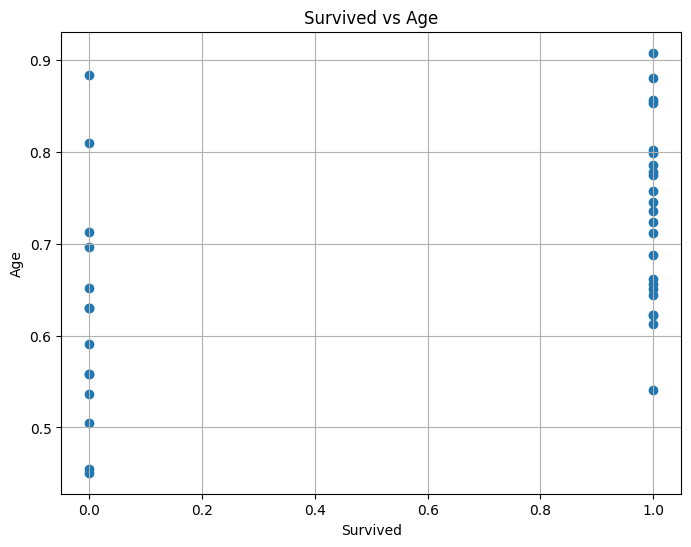

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    prediction
)

plt.xlabel("Survived")

plt.ylabel("Age")

plt.title("Survived vs Age")

plt.grid(True)

plt.show()

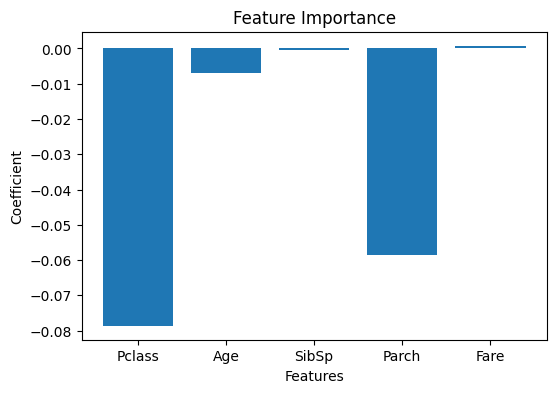

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Coefficient")

plt.show()


In [ ]:

print("\n")
print("="*60)
print("SUMMARY")
print("="*60)

print("""
1. Dataset Loaded Successfully

2. Selected Features:
      Sales
      Quantity
      Discount

3. Target Variable:
      Profit

4. Dataset Split:
      80% Training
      20% Testing

5. Linear Regression Model Trained

6. Predictions Generated

7. Model Evaluated using:
      MAE
      MSE
      RMSE
      R2 Score

8. Predicted Profit for New Orders

9. Visualized Model Performance

Machine Learning Workflow Completed Successfully.
""")



SUMMARY

1. Dataset Loaded Successfully

2. Selected Features:
      Sales
      Quantity
      Discount

3. Target Variable:
      Profit

4. Dataset Split:
      80% Training
      20% Testing

5. Linear Regression Model Trained

6. Predictions Generated

7. Model Evaluated using:
      MAE
      MSE
      RMSE
      R2 Score

8. Predicted Profit for New Orders

9. Visualized Model Performance

Machine Learning Workflow Completed Successfully.



In [ ]:
from google.colab import files
uploaded=files.upload()

Saving cardio_data_processed.csv to cardio_data_processed.csv


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

print("="*70)

In [ ]:
df_cardio = pd.read_csv('cardio_data_processed.csv')
display(df_cardio.head())

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal


In [ ]:

print("\nFirst Five Rows")
print(df.head())


First Five Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

In [ ]:
df = pd.read_csv("Titanic-Dataset (1).csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
print("\nDataset Information")
print(df.info())

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Shape of Dataset
(891, 12)

Column Names
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
